# Quora Question Pairs — final project

Task: classify whether a pair of questions are duplicates. Evaluation metric — **Cross-Entropy (Log) Loss**.

# Data Loading

If you are working in Google Colab — uncomment the cell below to connect to Google Drive, or upload the files directly using `files.upload()`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

pd.set_option('display.max_colwidth', 150)

from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, roc_auc_score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from scipy.sparse import hstack, csr_matrix
import xgboost as xgb

import re

import torch

In [2]:
train_df = pd.read_csv('./data/quora_question_pairs_train.csv')
test_df = pd.read_csv('./data/quora_question_pairs_test.csv')

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
train_df.head()

train_df shape: (323432, 6)
test_df shape: (80858, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three independent variables is also independent?,0
1,196656,297402,297403,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0
2,113125,184949,184950,How useful is MakeUseOf Answers?,"Is there any Q&A site that is not Yahoo answers, where hate speech is allowed?",0
3,266232,101283,163744,Which is the best place to reside in India and Why?,Which ia the best place to visit in India?,0
4,122738,17811,27517,Why do so many people ask questions on Quora that can be easily answered by any number of legitimate sources on the Web? Have they not heard of Go...,Why don't many people posting questions on Quora check Google first?,1


# EDA (Exploratory Data Analysis)

### General Overview: Types, Missing Values, Duplicates

In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 323432 entries, 0 to 323431
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            323432 non-null  int64
 1   qid1          323432 non-null  int64
 2   qid2          323432 non-null  int64
 3   question1     323431 non-null  str  
 4   question2     323430 non-null  str  
 5   is_duplicate  323432 non-null  int64
dtypes: int64(4), str(2)
memory usage: 51.8 MB


In [6]:
print("Missing values in train_df:")
print(train_df.isnull().sum())
print()
print("Missing values in test_df:")
print(test_df.isnull().sum())

Missing values in train_df:
id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

Missing values in test_df:
id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64


In [7]:
# There are very few missing values (1-2 rows) - we simply remove them
train_df = train_df.dropna(subset=['question1', 'question2']).reset_index(drop=True)
test_df = test_df.dropna(subset=['question1', 'question2']).reset_index(drop=True)

print('Train shape after cleaning:', train_df.shape)
print('Test shape after cleaning:', test_df.shape)

Train shape after cleaning: (323429, 6)
Test shape after cleaning: (80858, 6)


### Class Balance

In [9]:
class_balance_train = train_df['is_duplicate'].value_counts(normalize=True)
class_balance_test = test_df['is_duplicate'].value_counts(normalize=True)

print('Class distribution in train:')
print(class_balance_train)
print()
print('Class distribution in test:')
print(class_balance_test)

Class distribution in train:
is_duplicate
0    0.6308
1    0.3692
Name: proportion, dtype: float64

Class distribution in test:
is_duplicate
0    0.630797
1    0.369203
Name: proportion, dtype: float64


**Conclusion:** the class distribution in train_df and test_df is identical — ~63% non-duplicates, ~37% duplicates.

## Examples of duplicates and non-duplicates

In [12]:
# Examples of duplicates
train_df[train_df.is_duplicate == 1][['question1', 'question2']].sample(15, random_state=42)

,question1,question2
155515,What about the IAS coaching at Mukherjee Nagar?,What are the best IAS coaching centres in Mukherjee Nagar?
205599,Why did Sanskrit fail to become a suitable language for computers?,It has been claimed several times that Sanskrit is the most suitable language for computers. How can it be so?
227935,How will demonitization stop black money?,Will demonetisation really curb black money?
222776,How can i get rid of lower back pain?,How do I reduce lower back pain?
138763,Did nasa really go to the moon?,Did man really land on the moon?
115297,Why are you voting for Hillary Clinton?,Why do you support Hillary Clinton?
147856,"Will a Blu Ray play on a regular DVD player? If so, how?",How can you play a Blu Ray DVD on a regular DVD player?
290434,What are the benefits of daily flossing?,What are some of the benefits of flossing?
148914,What are some ways to quit bad habits?,What are your best tips to break bad habits?
264469,Where can I find the best quality cupcakes in Gold Coast?,Where can I get wonderful flavors on cupcakes in Gold Coast?


In [13]:
# Examples of non-duplicates
train_df[train_df.is_duplicate == 0][['question1', 'question2']].sample(10, random_state=42)

,question1,question2
103310,What does a wife expects from his husband?,What do husbands want from wives?
183078,What is the solution to this problem?,What is the solution of this problem?
238598,How sanitary is the International Space Station?,How airtight is the International Space Station?
264190,What is a pet?,What does your pet think of you?
137635,How big of a ducted fan would be needed to produce a thrust equal to that of a jet engine?,Why are jet engines so difficult to manufacture?
115484,How can one unblock himself from someone who blocked him?,How do I unblock myself from someone who has blocked me in whatsapp?
60590,What is it like living as an expat American in Bogota Colombia?,Which subject should I choose after 10th? I am very good at Maths but I wanna become a lawyer overseas. Should I opt for Humanities or Mathematics?
101645,What's the best way to learn SQL Server?,"What is the difference between MySql, Oracle, Microsoft SQL Server, SQL Lite? Is it necessary to learn SQL for all of them?"
247823,What is the meaning of Marathi word 'Kombdi'?,What is the meaning of Marathi word 'Jaahir'?
60471,"Which is a good solar panel installation provider near Mc Kittrick, California CA?","Which is a good solar panel installation provider in Alhambra, California CA?"


### Text Length Analysis

In [16]:
train_df['question1_char_len'] = train_df['question1'].str.len()
train_df['question2_char_len'] = train_df['question2'].str.len()
train_df['question1_word_len'] = train_df['question1'].str.split().apply(len)
train_df['question2_word_len'] = train_df['question2'].str.split().apply(len)

# Display descriptive statistics for character and word lengths of questions
train_df[['question1_char_len', 'question2_char_len', 'question1_word_len', 'question2_word_len']].describe()

,question1_char_len,question2_char_len,question1_word_len,question2_word_len
count,323429.000000,323429.000000,323429.000000,323429.000000
mean,59.531761,60.123242,10.941715,11.184554
std,29.921286,33.889595,5.426282,6.312174
min,1.000000,1.000000,1.000000,1.000000
25%,39.000000,39.000000,7.000000,7.000000
50%,52.000000,51.000000,10.000000,10.000000
75%,72.000000,72.000000,13.000000,13.000000
max,623.000000,1169.000000,125.000000,237.000000


In [17]:
train_df['char_len_diff'] = (train_df['question1_char_len'] - train_df['question2_char_len']).abs()  # Calculate the absolute difference in character lengths
train_df['word_len_diff'] = (train_df['question1_word_len'] - train_df['question2_word_len']).abs()  # Calculate the absolute difference in word lengths

In [18]:
print('Statistics of length (in words) by classes:')
train_df.groupby('is_duplicate')[['question1_word_len', 'question2_word_len', 'word_len_diff']].describe().T

Statistics of length (in words) by classes:


is_duplicate                          0              1
question1_word_len count  204019.000000  119410.000000
                   mean       11.582039       9.847684
                   std         5.947710       4.173048
                   min         1.000000       1.000000
                   25%         8.000000       7.000000
                   50%        10.000000       9.000000
                   75%        14.000000      11.000000
                   max       125.000000      80.000000
question2_word_len count  204019.000000  119410.000000
                   mean       11.962700       9.855046
                   std         7.172702       4.149137
                   min         1.000000       1.000000
                   25%         8.000000       7.000000
                   50%        10.000000       9.000000
                   75%        14.000000      11.000000
                   max       237.000000      60.000000
word_len_diff      count  204019.000000  119410.000000
                   mean        4.437626       2.422452
                   std         5.600733       2.690384
                   min         0.000000       0.000000
                   25%         1.000000       1.000000
                   50%         3.000000       2.000000
                   75%         6.000000       3.000000
                   max       223.000000      39.000000

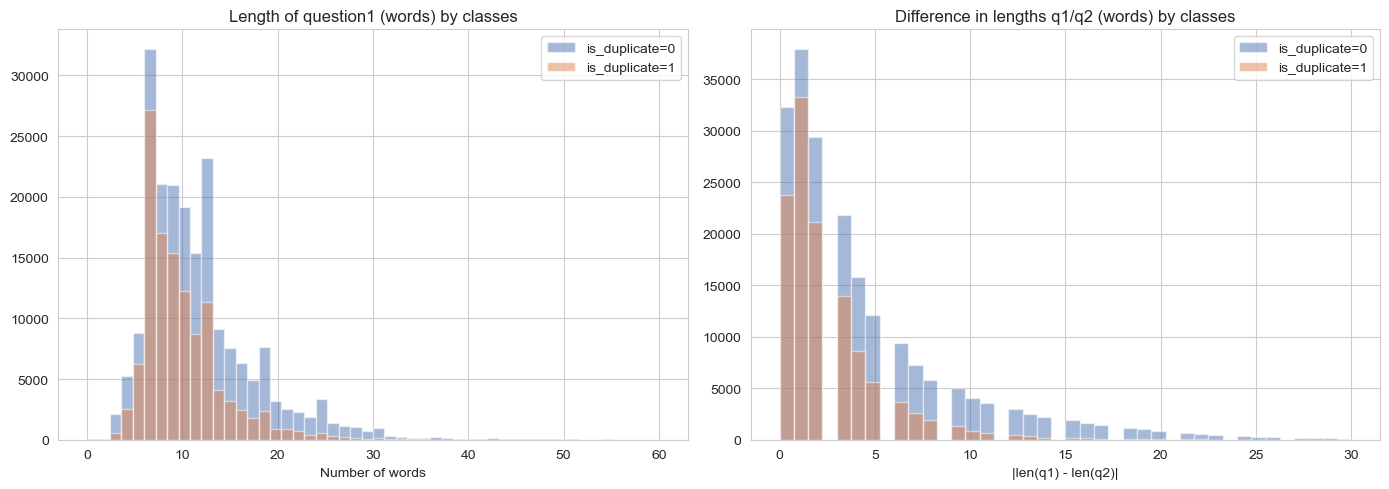

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    subset = train_df[train_df.is_duplicate == label]
    axes[0].hist(subset['question1_word_len'], bins=50, alpha=0.5, label=f'is_duplicate={label}', color=color, range=(0, 60))
axes[0].set_title('Length of question1 (words) by classes')
axes[0].set_xlabel('Number of words')
axes[0].legend()

for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    subset = train_df[train_df.is_duplicate == label]
    axes[1].hist(subset['word_len_diff'], bins=40, alpha=0.5, label=f'is_duplicate={label}', color=color, range=(0, 30))
axes[1].set_title('Difference in lengths q1/q2 (words) by classes')
axes[1].set_xlabel('|len(q1) - len(q2)|')
axes[1].legend()

plt.tight_layout()
plt.show()

**Conclusion:** The distributions of question lengths for both classes are very similar — there is no significant difference. However, the difference in lengths q1/q2 is slightly smaller in duplicates.

# Word Overlap Analysis

In [24]:
english_stopwords = set(stopwords.words('english'))

def get_word_set(text):
    """Tokenization using simple split() + converting to lowercase + removing stop words"""
    words = str(text).lower().split()
    return set(w for w in words if w not in english_stopwords)

def word_share(row):
    """Share of common words relative to the total number of unique words (Jaccard similarity)"""
    w1 = get_word_set(row['question1'])
    w2 = get_word_set(row['question2'])
    if len(w1) == 0 and len(w2) == 0:
        return 0.0
    common = w1 & w2
    union = w1 | w2
    return len(common) / len(union) if len(union) > 0 else 0.0

train_df['word_share'] = train_df.apply(word_share, axis=1)
train_df[['question1', 'question2', 'is_duplicate', 'word_share']].sample(5, random_state=1)

,question1,question2,is_duplicate,word_share
16311,How do we predict the weather?,Meteorology: Why is still so hard to predict weather accurately and precisely?,0,0.125000
114251,Which is the best honeymoon destination outside of India?,Which are the best honeymoon destination in India for summer?,0,0.428571
88285,"According to Culture Minister of India, the foreign women should not wear skirts while visiting India. Can they wear frock insead?",How can you calculate the average human walking pace?,0,0.000000
185491,What do minor league baseball players do while on the road?,What is the best Major League Baseball park?,0,0.250000
283792,What is the Mobvista 700 folder on my phone and can I delete it without causing problems to my phone?,How do I reinstall an app which was deleted using Superuser without a backup? Now my phone is not starting up. What is the process to do it?,0,0.105263


In [26]:
print('Average word_share by classes:')
print(train_df.groupby('is_duplicate')['word_share'].describe())

Average word_share by classes:
                 count      mean       std  min   25%       50%       75%  max
is_duplicate                                                                  
0             204019.0  0.225149  0.234606  0.0  0.00  0.153846  0.333333  1.0
1             119410.0  0.442092  0.228458  0.0  0.25  0.375000  0.571429  1.0


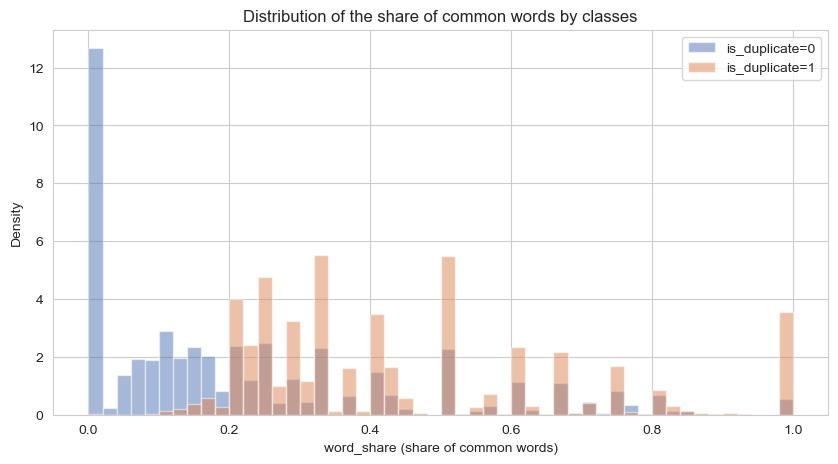

In [28]:
plt.figure(figsize=(10, 5))
for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    subset = train_df[train_df.is_duplicate == label]
    plt.hist(subset['word_share'], bins=50, alpha=0.5, label=f'is_duplicate={label}', color=color, density=True)
plt.title('Distribution of the share of common words by classes')
plt.xlabel('word_share (share of common words)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [30]:
correlation = train_df[['word_share', 'is_duplicate']].corr().iloc[0, 1]
print(f'Correlation of word_share with is_duplicate: {correlation:.3f}')

Correlation of word_share with is_duplicate: 0.411


**Conclusion:** The distributions of `word_share` for the two classes are noticeably different: the median for duplicates is significantly higher than for non-duplicates. The correlation with `is_duplicate` is moderately strong for such a simple feature. This confirms that features based on word overlap are very useful.

**Conclusion:** the share of common words is significantly higher for duplicates — this is already a strong baseline feature that should be used in the future.

### Most Frequent Words

In [38]:
SAMPLE_SIZE = 60000
sample_df = train_df.sample(SAMPLE_SIZE, random_state=42)

def tokenize_clean(text):
    words = str(text).lower().split()
    return [w for w in words if w.isalpha() and w not in english_stopwords]

dup_words = []
non_dup_words = []

for _, row in sample_df.iterrows():
    tokens = tokenize_clean(row['question1']) + tokenize_clean(row['question2'])
    if row['is_duplicate'] == 1:
        dup_words.extend(tokens)
    else:
        non_dup_words.extend(tokens)

dup_counter = Counter(dup_words)
non_dup_counter = Counter(non_dup_words)

print('Top 15 words in DUPLICATES:')
print(dup_counter.most_common(15))
print()
print('Top 15 words in NON-DUPLICATES:')
print(non_dup_counter.most_common(15))

Top 15 words in DUPLICATES:
[('best', 5151), ('get', 2084), ('people', 1416), ('would', 1260), ('way', 1228), ('make', 1093), ('good', 1086), ('money', 947), ('learn', 943), ('quora', 903), ('one', 894), ('like', 893), ('trump', 859), ('think', 805), ('india', 761)]

Top 15 words in NON-DUPLICATES:
[('best', 5286), ('get', 3626), ('like', 2497), ('good', 2475), ('would', 2249), ('people', 2127), ('one', 1665), ('make', 1552), ('way', 1399), ('much', 1374), ('difference', 1355), ('know', 1355), ('many', 1297), ('use', 1250), ('new', 1182)]


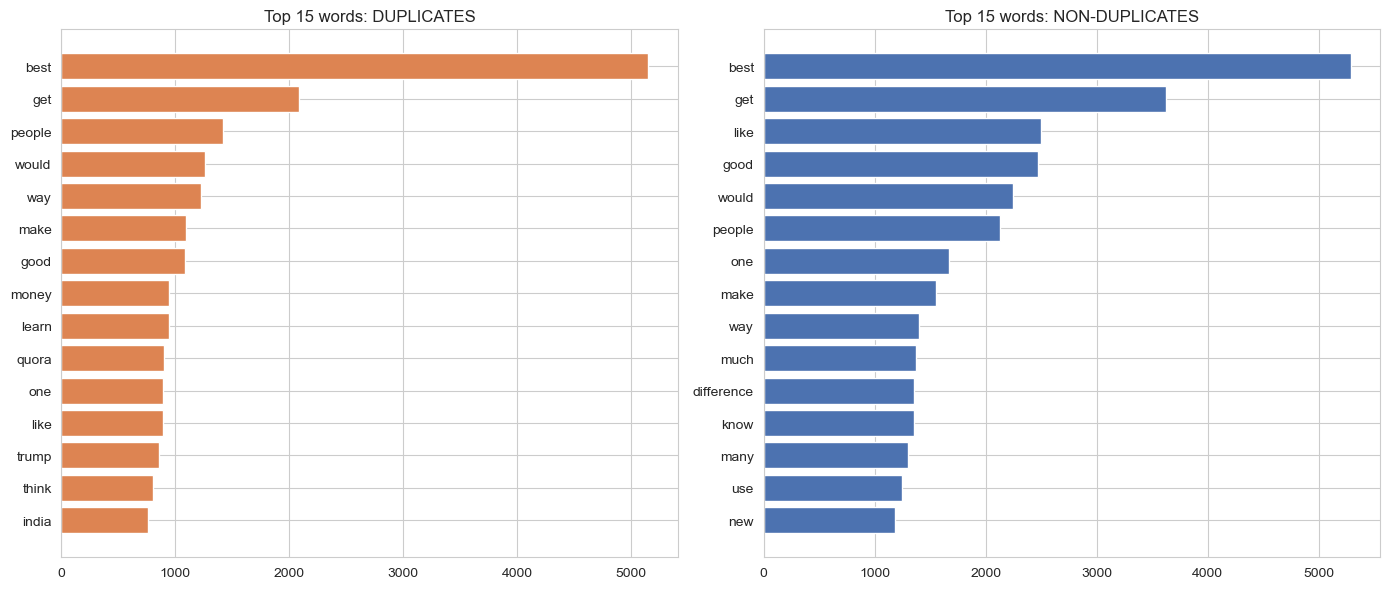

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_dup = dup_counter.most_common(15)
axes[0].barh([w for w, c in top_dup][::-1], [c for w, c in top_dup][::-1], color='#DD8452')
axes[0].set_title('Top 15 words: DUPLICATES')

top_non_dup = non_dup_counter.most_common(15)
axes[1].barh([w for w, c in top_non_dup][::-1], [c for w, c in top_non_dup][::-1], color='#4C72B0')
axes[1].set_title('Top 15 words: NON-DUPLICATES')

plt.tight_layout()
plt.show()

**Conclusion:** The top words in both classes are very similar in composition (common question words: `best`, `get`, `would`, `people`, `like`, etc.). This means that simple features like "the presence of word X" will be weak on their own. Much more important here is the overlap of words in the questions.

### Analysis of Question Recurrence in Different Pairs

In [44]:
all_qids = pd.concat([train_df['qid1'], train_df['qid2']])
unique_questions = all_qids.nunique()
total_occurrences = len(all_qids)

print(f'Unique questions (qid) in train: {unique_questions}')
print(f'Total number of occurrences: {total_occurrences}')
print(f'Average number of appearances of one question: {total_occurrences / unique_questions:.2f}')

qid_counts = all_qids.value_counts()
print(f'\nQuestions that appear more than once: {(qid_counts > 1).sum()} ({(qid_counts > 1).mean()*100:.1f}%)')

Unique questions (qid) in train: 449787
Total number of occurrences: 646858
Average number of appearances of one question: 1.44

Questions that appear more than once: 85896 (19.1%)


**Conclusion:** A significant portion of the questions is repeated in several pairs. It is important to keep this in mind during the train/val split stage.

### EDA Summary

1. **The data is clean** — there are almost no missing values (1-2 rows), which were easily removed.
2. **Moderate class imbalance**: ~63% non-duplicates / ~37% duplicates, equally in train and test.
3. **Text length weakly separates classes** — distributions are similar, although the difference in lengths q1/q2 is slightly smaller for duplicates.
4. **Word overlap — a strong feature**: clearly different distributions for duplicates and non-duplicates, moderate correlation with the target variable.
5. **Absolute word frequency is not very informative** — top words are similar in both classes, so more important features are at the level of *pair comparison*, rather than individual words.
6. **Questions repeat in several pairs** — this needs to be considered when splitting into train/val.

# Text Preprocessing

We keep only alphabetical tokens (removing numbers and punctuation).

In [53]:
stemmer = SnowballStemmer(language='english')
english_stopwords = set(stopwords.words('english'))

def preprocess_text(text):
    """Tokenization + lowercasing + stopword removal + stemming"""
    tokens = word_tokenize(str(text).lower())
    tokens = [stemmer.stem(t) for t in tokens if t.isalpha() and t not in english_stopwords]
    return tokens

# Quick check with an example
example = train_df['question1'].iloc[5]
print('Before processing:', example)
print('After processing:', preprocess_text(example))

Before processing: I got a seat in engineering management in Kettering University. Is that good to go? Will that build my career? What opportunities will I have after doing that course?
After processing: ['got', 'seat', 'engin', 'manag', 'ketter', 'univers', 'good', 'go', 'build', 'career', 'opportun', 'cours']


In [54]:
%%time
# Applying to the entire train
train_df['q1_tokens'] = train_df['question1'].apply(preprocess_text)
train_df['q2_tokens'] = train_df['question2'].apply(preprocess_text)

CPU times: user 1min 13s, sys: 608 ms, total: 1min 14s
Wall time: 1min 14s


In [55]:
%%time
# Applying to test
test_df['q1_tokens'] = test_df['question1'].apply(preprocess_text)
test_df['q2_tokens'] = test_df['question2'].apply(preprocess_text)

CPU times: user 17.7 s, sys: 87.4 ms, total: 17.8 s
Wall time: 17.9 s


In [56]:
# Text representation of processed tokens
train_df['q1_processed'] = train_df['q1_tokens'].apply(lambda t: ' '.join(t))
train_df['q2_processed'] = train_df['q2_tokens'].apply(lambda t: ' '.join(t))
test_df['q1_processed'] = test_df['q1_tokens'].apply(lambda t: ' '.join(t))
test_df['q2_processed'] = test_df['q2_tokens'].apply(lambda t: ' '.join(t))

train_df[['question1', 'q1_processed', 'question2', 'q2_processed']].head(5)

,question1,q1_processed,question2,q2_processed
0,The Iliad and the Odyssey in the Greek culture?,iliad odyssey greek cultur,How do I prove that the pairs of three independent variables is also independent?,prove pair three independ variabl also independ
1,What is practical management and what is strategic management?,practic manag strateg manag,What are the practical aspects of strategic management?,practic aspect strateg manag
2,How useful is MakeUseOf Answers?,use makeuseof answer,"Is there any Q&A site that is not Yahoo answers, where hate speech is allowed?",q site yahoo answer hate speech allow
3,Which is the best place to reside in India and Why?,best place resid india,Which ia the best place to visit in India?,ia best place visit india
4,Why do so many people ask questions on Quora that can be easily answered by any number of legitimate sources on the Web? Have they not heard of Go...,mani peopl ask question quora easili answer number legitim sourc web heard googl bing,Why don't many people posting questions on Quora check Google first?,mani peopl post question quora check googl first


## Feature Construction Based on Word Overlap

In EDA, we observed that the share of common words (`word_share`) effectively separates the classes. Now we will build a complete set of features based on this idea, using the already cleaned tokens.

In [62]:
def build_overlap_features(df):
    common_words = df.apply(lambda r: set(r['q1_tokens']) & set(r['q2_tokens']), axis=1)
    union_words = df.apply(lambda r: set(r['q1_tokens']) | set(r['q2_tokens']), axis=1)

    df['common_word_count'] = common_words.apply(len)
    df['union_word_count'] = union_words.apply(len)
    df['word_share_jaccard'] = df['common_word_count'] / df['union_word_count'].replace(0, np.nan)
    df['word_share_jaccard'] = df['word_share_jaccard'].fillna(0.0)

    df['q1_token_len'] = df['q1_tokens'].apply(len)
    df['q2_token_len'] = df['q2_tokens'].apply(len)

    # the share of common words relative to the shorter and longer question
    min_len = df[['q1_token_len', 'q2_token_len']].min(axis=1).replace(0, np.nan)
    max_len = df[['q1_token_len', 'q2_token_len']].max(axis=1).replace(0, np.nan)
    df['common_over_min_len'] = (df['common_word_count'] / min_len).fillna(0.0)
    df['common_over_max_len'] = (df['common_word_count'] / max_len).fillna(0.0)

    # the difference in lengths (in cleaned tokens and in raw characters)
    df['token_len_diff'] = (df['q1_token_len'] - df['q2_token_len']).abs()
    df['char_len_diff'] = (df['question1'].str.len() - df['question2'].str.len()).abs()

    return df

train_df = build_overlap_features(train_df)
test_df = build_overlap_features(test_df)

feature_cols = ['common_word_count', 'union_word_count', 'word_share_jaccard',
                 'common_over_min_len', 'common_over_max_len', 'token_len_diff', 'char_len_diff']

train_df[feature_cols + ['is_duplicate']].head(5)

,common_word_count,union_word_count,word_share_jaccard,common_over_min_len,common_over_max_len,token_len_diff,char_len_diff,is_duplicate
0,0,10,0.000000,0.000000,0.000000,3,34,0
1,3,4,0.750000,0.750000,0.750000,0,7,0
2,1,9,0.111111,0.333333,0.142857,4,46,0
3,3,6,0.500000,0.750000,0.600000,1,9,0
4,5,17,0.294118,0.625000,0.357143,6,91,1


In [63]:
print('Correlation of new features with is_duplicate:')
train_df[feature_cols + ['is_duplicate']].corr()['is_duplicate'].sort_values(ascending=False)

Correlation of new features with is_duplicate:


is_duplicate           1.000000
common_over_max_len    0.384865
word_share_jaccard     0.376572
common_over_min_len    0.373830
common_word_count      0.236985
char_len_diff         -0.209362
token_len_diff        -0.209637
union_word_count      -0.286445
Name: is_duplicate, dtype: float64

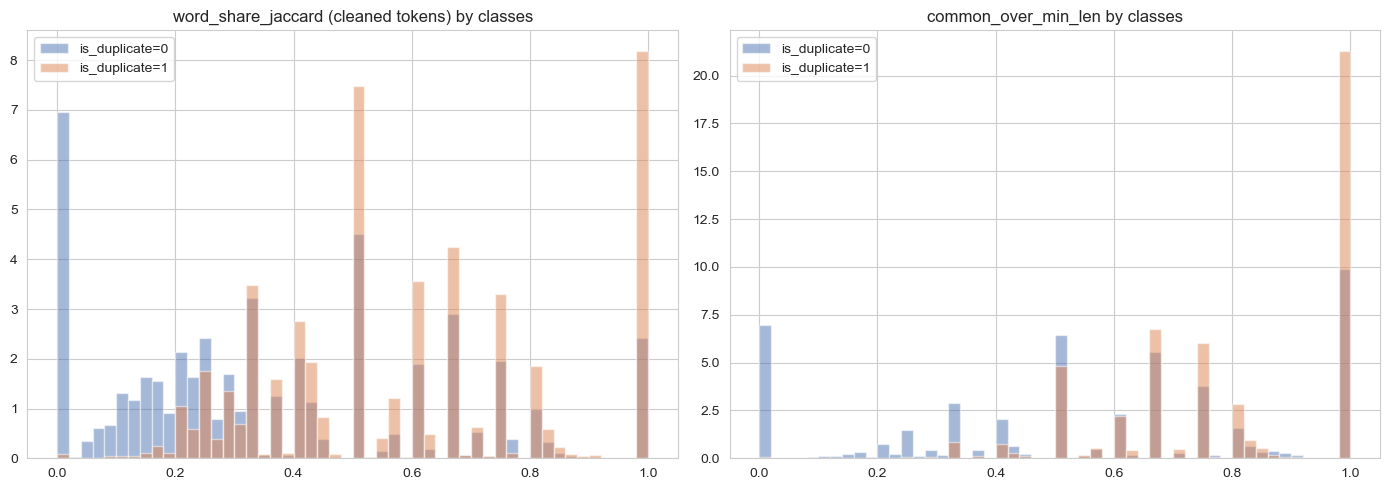

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    subset = train_df[train_df.is_duplicate == label]
    axes[0].hist(subset['word_share_jaccard'], bins=50, alpha=0.5, label=f'is_duplicate={label}', color=color, density=True)
axes[0].set_title('word_share_jaccard (cleaned tokens) by classes')
axes[0].legend()

for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    subset = train_df[train_df.is_duplicate == label]
    axes[1].hist(subset['common_over_min_len'], bins=50, alpha=0.5, label=f'is_duplicate={label}', color=color, density=True)
axes[1].set_title('common_over_min_len by classes')
axes[1].legend()

plt.tight_layout()
plt.show()

# Simple baseline without ML

In [66]:
# Naive baseline: always predicting class 0 (not a duplicate)
majority_class = train_df['is_duplicate'].mode()[0]
naive_preds = np.full(len(train_df), majority_class)

# For log loss, the naive baseline uses a constant probability = proportion of class 1 in train
# (this is the theoretically optimal constant probability for log loss)
train_prior = train_df['is_duplicate'].mean()
naive_proba = np.full(len(train_df), train_prior)

print(f'Naive baseline (always class {majority_class}):')
print(f'  Accuracy: {accuracy_score(train_df.is_duplicate, naive_preds):.4f}')
print(f'  F1: {f1_score(train_df.is_duplicate, naive_preds):.4f}')
print(f'  Log loss (constant probability = {train_prior:.3f}): {log_loss(train_df.is_duplicate, naive_proba):.4f}')

Naive baseline (always class 0):
  Accuracy: 0.6308
  F1: 0.0000
  Log loss (constant probability = 0.369): 0.6585


Best threshold based on F1: 0.30 (F1 = 0.6377)


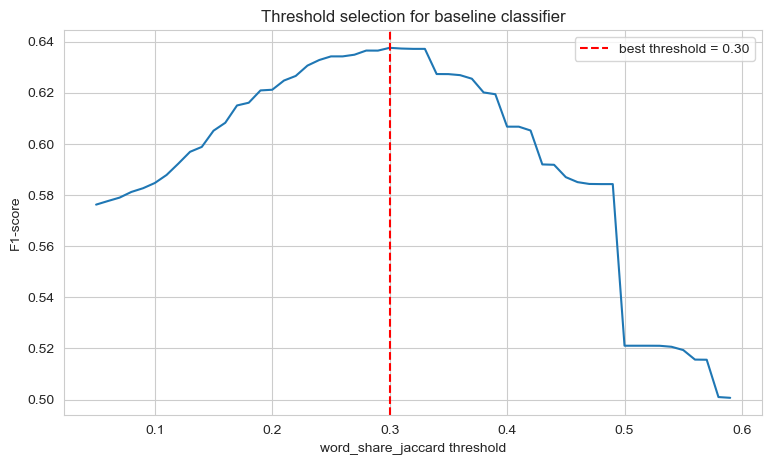

In [67]:
# Finding the optimal threshold for word_share_jaccard based on F1-score
thresholds = np.arange(0.05, 0.6, 0.01)
f1_scores = []

for t in thresholds:
    preds = (train_df['word_share_jaccard'] >= t).astype(int)
    f1_scores.append(f1_score(train_df['is_duplicate'], preds))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f'Best threshold based on F1: {best_threshold:.2f} (F1 = {f1_scores[best_idx]:.4f})')

plt.figure(figsize=(9, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'best threshold = {best_threshold:.2f}')
plt.xlabel('word_share_jaccard threshold')
plt.ylabel('F1-score')
plt.title('Threshold selection for baseline classifier')
plt.legend()
plt.show()

Baseline (threshold word_share_jaccard >= 0.30):
  Accuracy: 0.6329
  F1: 0.6377


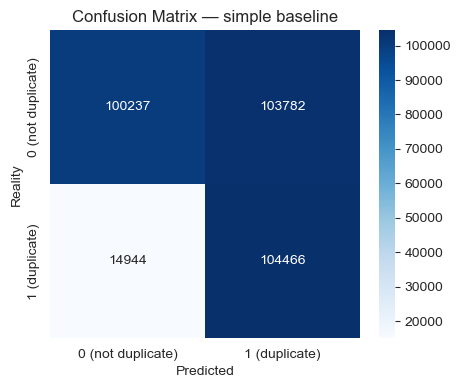

In [68]:
# Metrics with the best threshold
baseline_preds = (train_df['word_share_jaccard'] >= best_threshold).astype(int)

print(f'Baseline (threshold word_share_jaccard >= {best_threshold:.2f}):')
print(f'  Accuracy: {accuracy_score(train_df.is_duplicate, baseline_preds):.4f}')
print(f'  F1: {f1_score(train_df.is_duplicate, baseline_preds):.4f}')

cm = confusion_matrix(train_df.is_duplicate, baseline_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (not duplicate)', '1 (duplicate)'], yticklabels=['0 (not duplicate)', '1 (duplicate)'])
plt.xlabel('Predicted')
plt.ylabel('Reality')
plt.title('Confusion Matrix — simple baseline')
plt.show()

In [69]:
# Log loss: using word_share_jaccard directly as "probability", with clipping
# (without clipping, log loss can explode on examples with proba exactly 0 or 1)
baseline_proba = train_df['word_share_jaccard'].clip(0.02, 0.98)
baseline_log_loss = log_loss(train_df['is_duplicate'], baseline_proba)

print(f'Log loss of the naive baseline (constant): {log_loss(train_df.is_duplicate, naive_proba):.4f}')
print(f'Log loss of the baseline on word_share_jaccard (as proba): {baseline_log_loss:.4f}')

Log loss of the naive baseline (constant): 0.6585
Log loss of the baseline on word_share_jaccard (as proba): 0.6488


**Conclusion:** even the simplest baseline on one feature (`word_share_jaccard`) shows a significantly better F1 than naive majority prediction. Log loss also improves relative to the baseline, although it is still not a good result.

# Train/Val split considering repeated questions

We group questions using **Union-Find** — all pairs connected by a common `qid` fall into one group. Then we split into train/val by groups (`GroupShuffleSplit`), rather than by individual rows.

In [73]:
class UnionFind:
    def __init__(self):
        self.parent = {}

    def find(self, x):
        if x not in self.parent:
            self.parent[x] = x
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx != ry:
            self.parent[rx] = ry

uf = UnionFind()
for qid1, qid2 in zip(train_df['qid1'], train_df['qid2']):
    uf.union(qid1, qid2)

group_ids = train_df['qid1'].apply(uf.find).values
print(f'Number of independent question groups: {len(set(group_ids))} (from {len(train_df)} rows)')

Number of independent question groups: 172694 (from 323429 rows)


In [74]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(gss.split(train_df, groups=group_ids))

print(f'Train: {len(train_idx)} rows, Val: {len(val_idx)} rows')

# Check: no group should overlap between train and val
train_groups = set(group_ids[train_idx])
val_groups = set(group_ids[val_idx])
print('Overlap of train/val groups (should be 0):', len(train_groups & val_groups))

# Check class balance in both parts
print('Class balance train:', train_df.iloc[train_idx]['is_duplicate'].mean().round(4))
print('Class balance val:  ', train_df.iloc[val_idx]['is_duplicate'].mean().round(4))

Train: 266488 rows, Val: 56941 rows
Overlap of train/val groups (should be 0): 0
Class balance train: 0.3637
Class balance val:   0.3949


# TF-IDF Vectorization

`MAX_FEATURES=10000` for each question (i.e., 40000 after concatenation of q1+q2)

In [194]:
%%time
MAX_FEATURES = 10000

tfidf = TfidfVectorizer(max_features=MAX_FEATURES, min_df=3, token_pattern=r'\S+')
train_corpus = pd.concat([
    train_df.iloc[train_idx]['q1_processed'],
    train_df.iloc[train_idx]['q2_processed']
])
tfidf.fit(train_corpus)

print(f'Dictionary size: {len(tfidf.vocabulary_)}')

Dictionary size: 10000
CPU times: user 3.3 s, sys: 151 ms, total: 3.45 s
Wall time: 3.49 s


In [197]:
%%time
q1_tfidf_all = tfidf.transform(train_df['q1_processed'])
q2_tfidf_all = tfidf.transform(train_df['q2_processed'])
q1_tfidf_test = tfidf.transform(test_df['q1_processed'])
q2_tfidf_test = tfidf.transform(test_df['q2_processed'])

print('q1 TF-IDF shape:', q1_tfidf_all.shape)

q1 TF-IDF shape: (323429, 10000)
CPU times: user 4.98 s, sys: 109 ms, total: 5.09 s
Wall time: 5.13 s


## Features of similarity in vectors

In [199]:
def compute_similarity_features(q1_vec, q2_vec):
    """Cosine similarity + Euclidean/Manhattan distance between corresponding rows"""
    dot = np.array(q1_vec.multiply(q2_vec).sum(axis=1)).flatten()
    norm1 = np.sqrt(np.array(q1_vec.multiply(q1_vec).sum(axis=1)).flatten())
    norm2 = np.sqrt(np.array(q2_vec.multiply(q2_vec).sum(axis=1)).flatten())
    denom = norm1 * norm2
    cosine_sim = np.divide(dot, denom, out=np.zeros_like(dot), where=denom != 0)

    diff = q1_vec - q2_vec
    euclidean = np.sqrt(np.array(diff.multiply(diff).sum(axis=1)).flatten())
    manhattan = np.array(np.abs(diff).sum(axis=1)).flatten()

    return cosine_sim, euclidean, manhattan

cosine_all, euclidean_all, manhattan_all = compute_similarity_features(q1_tfidf_all, q2_tfidf_all)
cosine_test, euclidean_test, manhattan_test = compute_similarity_features(q1_tfidf_test, q2_tfidf_test)

train_df['tfidf_cosine'] = cosine_all
train_df['tfidf_euclidean'] = euclidean_all
train_df['tfidf_manhattan'] = manhattan_all
test_df['tfidf_cosine'] = cosine_test
test_df['tfidf_euclidean'] = euclidean_test
test_df['tfidf_manhattan'] = manhattan_test

print('Correlation of new features with is_duplicate:')
train_df[['tfidf_cosine', 'tfidf_euclidean', 'tfidf_manhattan', 'is_duplicate']].corr()['is_duplicate']

Correlation of new features with is_duplicate:


tfidf_cosine       0.362028
tfidf_euclidean   -0.336093
tfidf_manhattan   -0.361489
is_duplicate       1.000000
Name: is_duplicate, dtype: float64

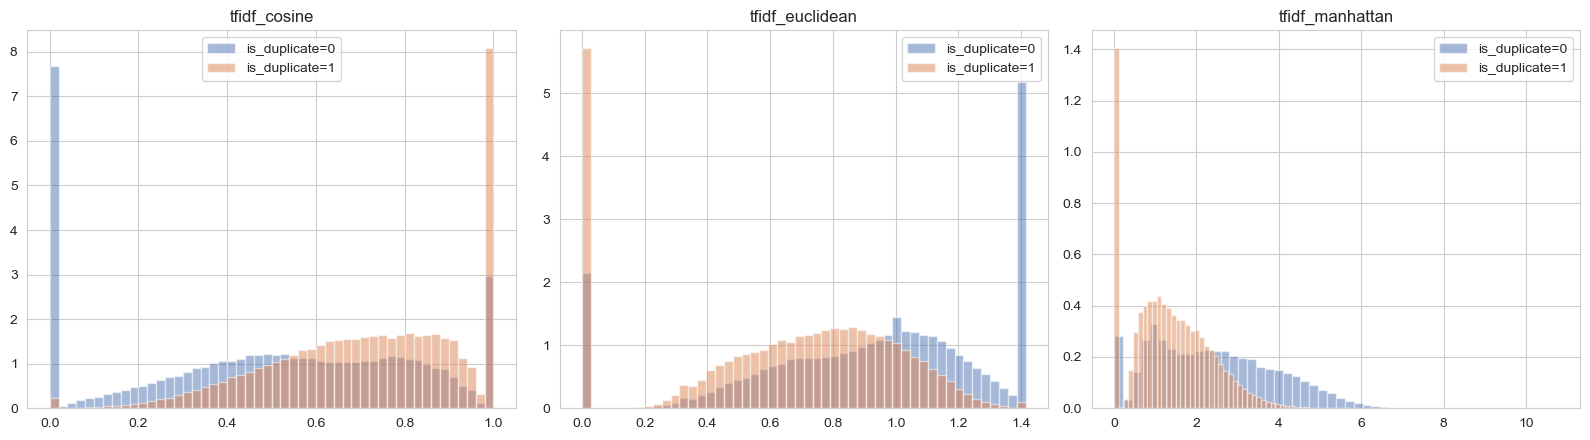

In [200]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['tfidf_cosine', 'tfidf_euclidean', 'tfidf_manhattan']):
    for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
        subset = train_df[train_df.is_duplicate == label]
        ax.hist(subset[col], bins=50, alpha=0.5, label=f'is_duplicate={label}', color=color, density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

**Conclusion:** `tfidf_cosine` provides a clearer separation of classes among vector features. This makes sense, as TF-IDF cosine takes into account not only the fact of word matching but also their weight (rare words carry more weight).

## Building the Final Feature Matrix

We combine: TF-IDF vectors q1 and q2 + similarity features + word intersection and lengths. 
We scale the numerical features (not TF-IDF) using `StandardScaler`, as `LogisticRegression` is sensitive to different scales of features.

In [203]:
feature_cols = ['common_word_count', 'union_word_count', 'word_share_jaccard', 'common_over_min_len', 'common_over_max_len', 
                'token_len_diff', 'char_len_diff', 'tfidf_cosine', 'tfidf_euclidean', 'tfidf_manhattan']

scaler = StandardScaler()
extra_train_scaled = scaler.fit_transform(train_df.iloc[train_idx][feature_cols])
extra_all_scaled = scaler.transform(train_df[feature_cols])
extra_test_scaled = scaler.transform(test_df[feature_cols])

X_all = hstack([q1_tfidf_all, q2_tfidf_all, csr_matrix(extra_all_scaled)]).tocsr()
X_test = hstack([q1_tfidf_test, q2_tfidf_test, csr_matrix(extra_test_scaled)]).tocsr()

X_train = X_all[train_idx]
X_val = X_all[val_idx]
y_train = train_df.iloc[train_idx]['is_duplicate'].values
y_val = train_df.iloc[val_idx]['is_duplicate'].values
y_test = test_df['is_duplicate'].values

print('X_train shape:', X_train.shape)
print('X_val shape:', X_val.shape)
print('X_test shape:', X_test.shape)

X_train shape: (266488, 20010)
X_val shape: (56941, 20010)
X_test shape: (80858, 20010)


In [204]:
def add_result(results, model_name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    row = {
        'model': model_name,
        'log_loss': log_loss(y_true, y_proba),
        'f1': f1_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

    results.loc[len(results)] = row
    display(results)

    return results

train_results = pd.DataFrame([
    {
        'model': 'Наївний baseline (константа)',
        'log_loss': log_loss(y_train, np.full(len(y_train), y_train.mean())),
        'f1': 0.0,
        'accuracy': (y_train == 0).mean(),
        'roc_auc': 0.5
    },
    {
        'model': 'Поріг на word_share_jaccard',
        'log_loss': log_loss(y_train, train_df.iloc[train_idx]['word_share_jaccard'].clip(0.02, 0.98)),
        'f1': f1_score(y_train, (train_df.iloc[train_idx]['word_share_jaccard'] >= 0.30).astype(int)),
        'accuracy': accuracy_score(y_train, (train_df.iloc[train_idx]['word_share_jaccard'] >= 0.30).astype(int)),
        'roc_auc': roc_auc_score(y_train, train_df.iloc[train_idx]['word_share_jaccard'])
    }
])

val_results = pd.DataFrame([
    {
        'model': 'Наївний baseline (константа)',
        'log_loss': log_loss(y_val, np.full(len(y_val), y_train.mean())),
        'f1': 0.0,
        'accuracy': (y_val == 0).mean(),
        'roc_auc': 0.5
    },
    {
        'model': 'Поріг на word_share_jaccard',
        'log_loss': log_loss(y_val, train_df.iloc[val_idx]['word_share_jaccard'].clip(0.02, 0.98)),
        'f1': f1_score(y_val, (train_df.iloc[val_idx]['word_share_jaccard'] >= 0.30).astype(int)),
        'accuracy': accuracy_score(y_val, (train_df.iloc[val_idx]['word_share_jaccard'] >= 0.30).astype(int)),
        'roc_auc': roc_auc_score(y_val, train_df.iloc[val_idx]['word_share_jaccard'])
    }
])

# Model 1: Logistic Regression

In [206]:
%%time
logreg = LogisticRegression(max_iter=300, solver='saga', random_state=42)
logreg.fit(X_train, y_train)

CPU times: user 54.8 s, sys: 226 ms, total: 55 s
Wall time: 55.4 s


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",300
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elasti

In [209]:
train_proba_lr = logreg.predict_proba(X_train)[:, 1]
train_preds_lr = (train_proba_lr >= 0.5).astype(int)

val_proba_lr = logreg.predict_proba(X_val)[:, 1]
val_preds_lr = (val_proba_lr >= 0.5).astype(int)

In [210]:
print('='*30+'Train'+'='*30)
train_results = add_result(
    train_results,
    'Logistic Regression (TF-IDF + features)',
    y_train,
    train_proba_lr
)

print('='*30+'Validation'+'='*30)
val_results = add_result(
    val_results,
    'Logistic Regression (TF-IDF + features)',
    y_val,
    val_proba_lr
)

==============================Train==============================


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.655518,0.000000,0.636299,0.500000
1,Поріг на word_share_jaccard,0.648484,0.632415,0.625364,0.732250
2,Logistic Regression (TF-IDF + features),0.426158,0.697843,0.790347,0.873204


==============================Validation==============================


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.672988,0.000000,0.605065,0.500000
1,Поріг на word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393


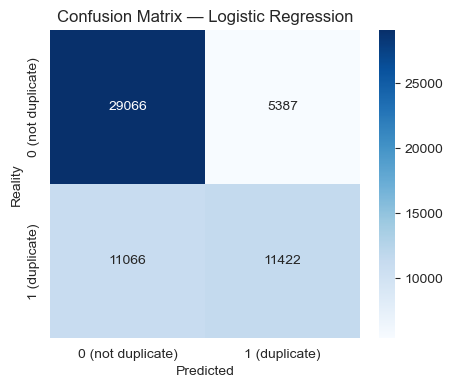

In [213]:
cm_lr = confusion_matrix(y_val, val_preds_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (not duplicate)', '1 (duplicate)'], yticklabels=['0 (not duplicate)', '1 (duplicate)'])
plt.xlabel('Predicted')
plt.ylabel('Reality')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

## Feature Importance for Logistic Regression

Let's take a closer look at the most influential words and the weight of the engineering features themselves.

In [216]:
feature_names = (
    ['q1__' + f for f in tfidf.get_feature_names_out()] +
    ['q2__' + f for f in tfidf.get_feature_names_out()] +
    feature_cols
)

feature_importance = pd.Series(logreg.coef_[0], index=feature_names, name='coef').sort_values(ascending=False)

print('Top-15 features that MOST indicate a DUPLICATE:')
print(feature_importance.head(15))
print()
print('Top-15 features that MOST indicate a NON-DUPLICATE:')
print(feature_importance.tail(15))

Top-15 features that MOST indicate a DUPLICATE:
q1__note         2.834146
q2__note         2.643973
q1__meth         2.546820
q2__meth         2.342402
q1__rs           2.311687
q1__earthquak    2.309583
q2__resolut      2.285263
q2__earthquak    2.241414
q2__infinit      2.216457
q2__easili       2.197068
q1__resolut      2.102387
q2__exact        2.095158
q1__fluentli     2.045205
q2__trump        2.035339
q1__sahara       2.033516
Name: coef, dtype: float64

Top-15 features that MOST indicate a NON-DUPLICATE:
q1__counti         -1.533929
q1__symbol         -1.551042
q1__sentenc        -1.580377
q1__invit          -1.611103
q1__depart         -1.668856
q2__particular     -1.813471
q1__corpor         -1.894817
q2__visitor        -2.084844
q2__grad           -2.107470
q1__compar         -2.144084
q1__grad           -2.212818
union_word_count   -2.248940
q1__visitor        -2.623661
q1__employe        -3.699482
q2__employe        -3.897738
Name: coef, dtype: float64


In [217]:
feature_importance.loc[feature_cols].sort_values(ascending=False)

tfidf_manhattan        1.923568
common_word_count      1.216509
common_over_max_len    0.943800
tfidf_cosine           0.450424
token_len_diff         0.181280
common_over_min_len    0.159631
char_len_diff         -0.141246
tfidf_euclidean       -0.803965
word_share_jaccard    -1.165531
union_word_count      -2.248940
Name: coef, dtype: float64

**Conclusion:** As expected, the engineering features (`union_word_count`, `tfidf_manhattan`, `word_share_jaccard`, `common_word_count`) have some of the largest coefficients in absolute value — the model confirms the hypothesis from EDA. Among the words, specific words provide the strongest signal, which is logical, as their presence in both questions is strong evidence of topic similarity.

## Error Analysis

Let's look at specific examples of errors.

In [220]:
val_df = train_df.iloc[val_idx].copy()
val_df['pred_proba'] = val_proba_lr
val_df['pred'] = val_preds_lr
val_df['error_type'] = np.select(
    [(val_df.is_duplicate == 1) & (val_df.pred == 0),  # false negative
     (val_df.is_duplicate == 0) & (val_df.pred == 1)],  # false positive
    ['false_negative', 'false_positive'],
    default='correct'
)

print(val_df['error_type'].value_counts())

error_type
correct           40488
false_negative    11066
false_positive     5387
Name: count, dtype: int64


In [221]:
print('Examples of FALSE NEGATIVE (actual duplicate that the model missed):')
val_df[val_df.error_type == 'false_negative'][['question1', 'question2', 'pred_proba']].sample(10, random_state=1)

Examples of FALSE NEGATIVE (actual duplicate that the model missed):


,question1,question2,pred_proba
253600,Which test would be easier: IELTS or PTE (Pearson Test Of English)?,Is the PTE or IELTS easy?,0.337023
156476,How can a mosquito fly inside a moving car?,When a house fly enters a moving vehicle. does it move at the same speed of the car?,0.232003
268187,Which are the top places to visit in Kerala?,What are some good beaches to visit in Kerala?,0.429319
87989,How can I get my password back from Facebook if my email address doesn't exist anymore?,I forgot my password and also my email password. how can I get back that account?,0.372542
90861,Which are some of the best performing penny stocks in India?,What are some penny stocks I can buy in the Indian stock market?,0.132260
153237,Why do people talk about useless garbage or small talk?,Why do people make small talk?,0.219285
313125,Why do men love boobs (irrespective of big or small)?,Why men love boobs?,0.420438
163780,How do I decorate a bedroom with a 1980s theme?,How do I decorate a bedroom like it's the year 1980?,0.393557
179021,Why moving iron instruments work on AC and DC supply both but moving coil instruments work only in DC supply only ?,Why moving iron instrument is used for both ac and dc?,0.163073
121224,How can I grow taller?,In what ways can I grow taller?,0.489632


In [222]:
print('Examples of FALSE POSITIVE (the model incorrectly considers as duplicates):')
val_df[val_df.error_type == 'false_positive'][['question1', 'question2', 'pred_proba']].sample(10, random_state=1)

Examples of FALSE POSITIVE (the model incorrectly considers as duplicates):


,question1,question2,pred_proba
91743,What individuals and events in history are a source of pride for Algeria?,What individuals and events in history are a source of pride for China?,0.519855
122218,"What hotel in Pune would be safe for unmarried couples, without the harassment of police, hotel staff, and moral police?","What hotel in Raipur would be safe for unmarried couples, without the harassment of police, hotel staff, and moral police?",0.681938
253905,Why do I feel very lonely?,What should we do when we feel very lonely?,0.661003
295647,What are the some good books that keeps you motivated for a long time?,What are some good books on time travel?,0.644799
124956,"What hotel in Nahan Hill-station would be safe for unmarried couples, without the harassment of police, hotel staff, and moral police?","What hotel in Gangtok Hill-station would be safe for unmarried couples, without the harassment of police, hotel staff, and moral police?",0.694157
82005,"How do the Christianists perceive, feel, understand, view, believe, and/or opine, about Dalits, Shudras, and Dasa?","How do the Nepalese perceive, feel, understand, view, believe, and/or opine, about Dalits, Shudras, and Dasa?",0.680590
19267,What's the quickest way to get rid of belly fat?,"What are the best ways to reduce and eliminate belly, abdominal, and thigh fat?",0.549571
179814,"I've heard a lot about immigration problems in Sweden (no-go-zones, Sharia Law, crime), is the situation in Norway better or worse?","I've heard a lot about immigration problems in Sweden (no-go-zones, Sharia Law, crime), is the situation in Denmark better or worse?",0.872422
62746,How do I reset my Gmail password when I don't remember my recovery information? Request,How do I reset my Gmail password when I don't remember my recovery information?,0.668299
84559,Would you ever get bored of Quora?,Does anyone ever get bored from Quora?,0.969293


**Typical mistakes:**
- **False negative**: rephrased questions with almost completely different words (synonyms, different grammatical structure)
- **False positive**: questions on the same topic with a large lexical overlap, but different factual content

# Model 2: XGBoost

In [225]:
%%time
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

CPU times: user 3min 42s, sys: 1.87 s, total: 3min 44s
Wall time: 56.8 s


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [226]:
train_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
train_preds_xgb = (train_proba_xgb >= 0.5).astype(int)

val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
val_preds_xgb = (val_proba_xgb >= 0.5).astype(int)

In [227]:
print('='*30+'Train'+'='*30)
train_results = add_result(
    train_results,
    'XGBoost (TF-IDF)',
    y_train,
    train_proba_xgb
)

print('='*30+'Validation'+'='*30)
val_results = add_result(
    val_results,
    'XGBoost (TF-IDF)',
    y_val,
    val_proba_xgb
)

==============================Train==============================


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.655518,0.000000,0.636299,0.500000
1,Поріг на word_share_jaccard,0.648484,0.632415,0.625364,0.732250
2,Logistic Regression (TF-IDF + features),0.426158,0.697843,0.790347,0.873204
3,XGBoost (TF-IDF),0.448985,0.653174,0.774545,0.858775


==============================Validation==============================


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.672988,0.000000,0.605065,0.500000
1,Поріг на word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677


XGBoost achieved a better validation log loss (0.521 vs. 0.527 in LogReg), but **worse F1** (0.523 vs. 0.578) at a threshold of 0.5 and **slightly worse ROC-AUC** (0.798 vs. 0.804). This seems contradictory, and while F1 can be improved by changing the threshold, this won't work for ROC-AUC.

That's why I consider it reasonable to try Word2Vec in addition to TF-IDF for these models.

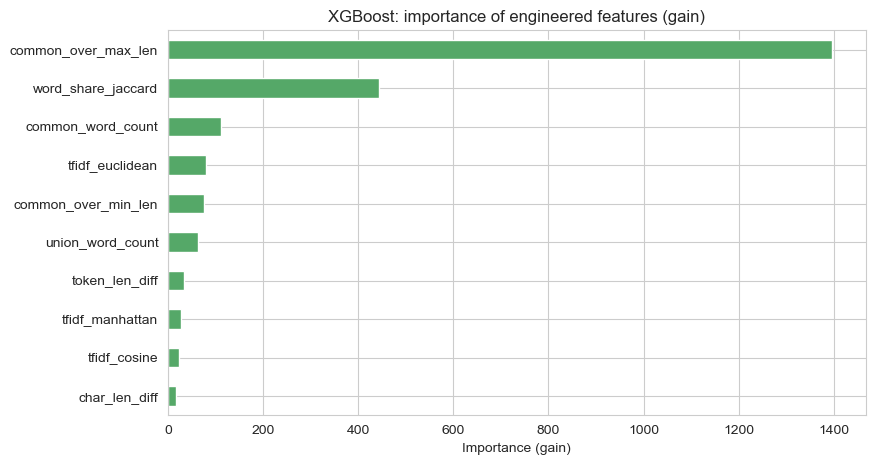

Top-15 features overall (including TF-IDF words):


common_over_max_len    1397.206909
word_share_jaccard      442.891602
q2__note                275.825073
q1__saltwat             274.248810
q2__quora               257.290955
q1__note                249.918076
q1__quora               233.729385
q1__temperatur          221.691589
q1__hillari             202.944214
q2__improv              190.119751
q1__cambodia            176.526031
q1__improv              175.555939
q2__saltwat             174.243942
q2__trump               169.574692
q2__word                168.826736
dtype: float64

In [229]:
# Feature importance for XGBoost - top engineered features (most interpretable)
importance_dict = xgb_model.get_booster().get_score(importance_type='gain')
importance_named = {feature_names[int(k[1:])]: v for k, v in importance_dict.items()}
importance_series = pd.Series(importance_named).sort_values(ascending=False)

# Filtering only engineered features for clarity (too many TF-IDF words for one graph)
engineered_importance = importance_series[importance_series.index.isin(feature_cols)]

plt.figure(figsize=(9, 5))
engineered_importance.sort_values().plot(kind='barh', color='#55A868')
plt.title('XGBoost: importance of engineered features (gain)')
plt.xlabel('Importance (gain)')
plt.show()

print('Top-15 features overall (including TF-IDF words):')
importance_series.head(15)

## Loading pre-trained word embeddings

In [245]:
import gensim.downloader as api
wv = api.load('word2vec-google-news-300')

In [246]:
import gc

def tokenize_light(text):
    return re.findall(r'\b[a-zA-Z]+\b', str(text).lower())

# We count tokens as simple Python lists
q1_tokens_train = [tokenize_light(t) for t in train_df['question1']]
q2_tokens_train = [tokenize_light(t) for t in train_df['question2']]

print('Example tokens:', q1_tokens_train[0])

Example tokens: ['the', 'iliad', 'and', 'the', 'odyssey', 'in', 'the', 'greek', 'culture']


In [247]:
%%time
def build_embedding_matrix(token_lists, model, word_to_idf=None):
    """Builds a dense embedding matrix (n x vector_size) without intermediate object columns"""
    n = len(token_lists)
    mat = np.zeros((n, model.vector_size), dtype=np.float32)
    for i, tokens in enumerate(token_lists):
        if word_to_idf is None:
            vecs = [model[w] for w in tokens if w in model]
            if vecs:
                mat[i] = np.mean(vecs, axis=0)
        else:
            vecs, weights = [], []
            for w in tokens:
                if w in model and w in word_to_idf:
                    vecs.append(model[w])
                    weights.append(word_to_idf[w])
            if vecs:
                mat[i] = np.average(np.array(vecs), axis=0, weights=np.array(weights))
    return mat

# TF-IDF (light, non-stemmed) fit only on the train part - for weighted averaging
train_text_light = [' '.join(q1_tokens_train[i] + q2_tokens_train[i]) for i in train_idx]
tfidf_light = TfidfVectorizer(token_pattern=r'\S+', min_df=2)
tfidf_light.fit(train_text_light)
word_to_idf = dict(zip(tfidf_light.get_feature_names_out(), tfidf_light.idf_))
print(f'TF-IDF dictionary size (light): {len(word_to_idf)}')

q1_avg_train = build_embedding_matrix(q1_tokens_train, wv)
q2_avg_train = build_embedding_matrix(q2_tokens_train, wv)
q1_weighted_train = build_embedding_matrix(q1_tokens_train, wv, word_to_idf)
q2_weighted_train = build_embedding_matrix(q2_tokens_train, wv, word_to_idf)

del q1_tokens_train, q2_tokens_train, train_text_light
gc.collect()
print('Train embeddings are ready:', q1_avg_train.shape)

TF-IDF dictionary size (light): 38188
Train embeddings are ready: (323429, 300)
CPU times: user 1min 6s, sys: 4.57 s, total: 1min 11s
Wall time: 1min 18s


In [248]:
%%time
q1_tokens_test = [tokenize_light(t) for t in test_df['question1']]
q2_tokens_test = [tokenize_light(t) for t in test_df['question2']]

q1_avg_test = build_embedding_matrix(q1_tokens_test, wv)
q2_avg_test = build_embedding_matrix(q2_tokens_test, wv)
q1_weighted_test = build_embedding_matrix(q1_tokens_test, wv, word_to_idf)
q2_weighted_test = build_embedding_matrix(q2_tokens_test, wv, word_to_idf)

del q1_tokens_test, q2_tokens_test
gc.collect()
print('Test embeddings are ready:', q1_avg_test.shape)

Test embeddings are ready: (80858, 300)
CPU times: user 15.1 s, sys: 951 ms, total: 16.1 s
Wall time: 17.5 s


## Similarity features between embeddings q1 and q2

In [250]:
def compute_dense_similarity(A, B):
    dot = np.sum(A * B, axis=1)
    norm_a = np.linalg.norm(A, axis=1)
    norm_b = np.linalg.norm(B, axis=1)
    denom = norm_a * norm_b
    cosine_sim = np.divide(dot, denom, out=np.zeros_like(dot), where=denom != 0)
    euclidean = np.linalg.norm(A - B, axis=1)
    manhattan = np.sum(np.abs(A - B), axis=1)
    return cosine_sim, euclidean, manhattan

# For average embeddings
cos_avg, eucl_avg, manh_avg = compute_dense_similarity(q1_avg_train, q2_avg_train)
train_df['w2v_avg_cosine'] = cos_avg
train_df['w2v_avg_euclidean'] = eucl_avg
train_df['w2v_avg_manhattan'] = manh_avg

# For weighted embeddings
cos_w, eucl_w, manh_w = compute_dense_similarity(q1_weighted_train, q2_weighted_train)
train_df['w2v_weighted_cosine'] = cos_w
train_df['w2v_weighted_euclidean'] = eucl_w
train_df['w2v_weighted_manhattan'] = manh_w

# The same for test
cos_avg_t, eucl_avg_t, manh_avg_t = compute_dense_similarity(q1_avg_test, q2_avg_test)
test_df['w2v_avg_cosine'], test_df['w2v_avg_euclidean'], test_df['w2v_avg_manhattan'] = cos_avg_t, eucl_avg_t, manh_avg_t
cos_w_t, eucl_w_t, manh_w_t = compute_dense_similarity(q1_weighted_test, q2_weighted_test)
test_df['w2v_weighted_cosine'], test_df['w2v_weighted_euclidean'], test_df['w2v_weighted_manhattan'] = cos_w_t, eucl_w_t, manh_w_t

w2v_sim_cols = ['w2v_avg_cosine', 'w2v_avg_euclidean', 'w2v_avg_manhattan',
                'w2v_weighted_cosine', 'w2v_weighted_euclidean', 'w2v_weighted_manhattan']

# Correlation with is_duplicate:
print('Кореляція з is_duplicate:')
train_df[w2v_sim_cols + ['is_duplicate']].corr()['is_duplicate']

Кореляція з is_duplicate:


w2v_avg_cosine            0.368103
w2v_avg_euclidean        -0.308168
w2v_avg_manhattan        -0.307693
w2v_weighted_cosine       0.378201
w2v_weighted_euclidean   -0.341806
w2v_weighted_manhattan   -0.341468
is_duplicate              1.000000
Name: is_duplicate, dtype: float64

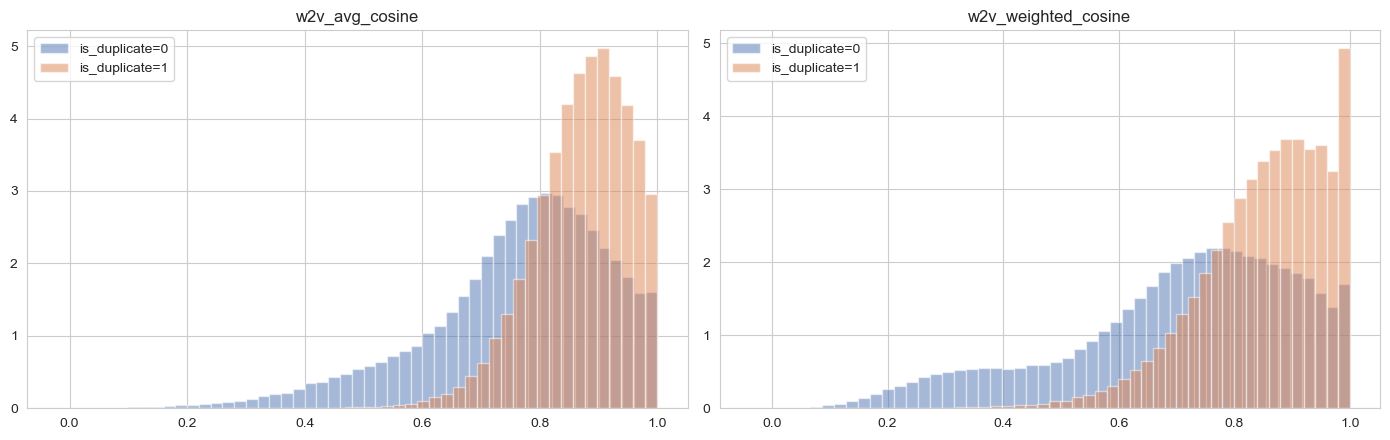

In [251]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, col in zip(axes, ['w2v_avg_cosine', 'w2v_weighted_cosine']):
    for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
        subset = train_df[train_df.is_duplicate == label]
        ax.hist(subset[col], bins=50, alpha=0.5, label=f'is_duplicate={label}', color=color, density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

# Building the feature matrix

In [253]:
engineered_features = ['common_word_count', 'union_word_count', 'word_share_jaccard',
                        'common_over_min_len', 'common_over_max_len', 'token_len_diff', 'char_len_diff']

In [254]:
extra_feature_cols = engineered_features + w2v_sim_cols

scaler = StandardScaler()
extra_train_scaled = scaler.fit_transform(train_df.iloc[train_idx][extra_feature_cols])
extra_all_scaled = scaler.transform(train_df[extra_feature_cols])
extra_test_scaled = scaler.transform(test_df[extra_feature_cols])

X_all = np.hstack([q1_weighted_train, q2_weighted_train, extra_all_scaled])
X_test = np.hstack([q1_weighted_test, q2_weighted_test, extra_test_scaled])

X_train = X_all[train_idx]
X_val = X_all[val_idx]
y_train = train_df.iloc[train_idx]['is_duplicate'].values
y_val = train_df.iloc[val_idx]['is_duplicate'].values
y_test = test_df['is_duplicate'].values

del q1_avg_train, q2_avg_train, q1_avg_test, q2_avg_test  # no longer needed directly
gc.collect()

print('X_train shape:', X_train.shape)  # 100 (q1) + 100 (q2) + engineered/similarity features

X_train shape: (266488, 613)


## Model 3: Logistic Regression on Word2Vec Features

In [256]:
%%time
logreg_w2v = LogisticRegression(max_iter=500, random_state=42)
logreg_w2v.fit(X_train, y_train)

CPU times: user 44.6 s, sys: 251 ms, total: 44.8 s
Wall time: 11.5 s


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [259]:
train_proba_lr_w2v = logreg_w2v.predict_proba(X_train)[:, 1]
train_preds_lr_w2v = (train_proba_lr_w2v >= 0.5).astype(int)

val_proba_lr_w2v = logreg_w2v.predict_proba(X_val)[:, 1]
val_preds_lr_w2v = (val_proba_lr_w2v >= 0.5).astype(int)

In [261]:
print('='*30+'Train'+'='*30)
train_results = add_result(
    train_results,
    'Logistic Regression (Word2Vec)',
    y_train,
    train_proba_lr_w2v
)

print('='*30+'Validation'+'='*30)
val_results = add_result(
    val_results,
    'Logistic Regression (Word2Vec)',
    y_val,
    val_proba_lr_w2v
)

==============================Train==============================


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.655518,0.000000,0.636299,0.500000
1,Поріг на word_share_jaccard,0.648484,0.632415,0.625364,0.732250
2,Logistic Regression (TF-IDF + features),0.426158,0.697843,0.790347,0.873204
3,XGBoost (TF-IDF),0.448985,0.653174,0.774545,0.858775
4,Logistic Regression (Word2Vec),0.492585,0.623092,0.735035,0.815719


==============================Validation==============================


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.672988,0.000000,0.605065,0.500000
1,Поріг на word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677
4,Logistic Regression (Word2Vec),0.531765,0.581234,0.700198,0.790394


## Model 4: XGBoost on Word2Vec features

In [270]:
%%time
xgb_w2v = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    random_state=42
)
xgb_w2v.fit(X_train, y_train)

CPU times: user 5min 39s, sys: 3.22 s, total: 5min 43s
Wall time: 1min 28s


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [271]:
train_proba_xgb_w2v = xgb_w2v.predict_proba(X_train)[:, 1]
train_preds_xgb_w2v = (train_proba_xgb_w2v >= 0.5).astype(int)

val_proba_xgb_w2v = xgb_w2v.predict_proba(X_val)[:, 1]
val_preds_xgb_w2v = (val_proba_xgb_w2v >= 0.5).astype(int)

In [274]:
print('='*30+'Train'+'='*30)
train_results = add_result(
    train_results,
    'XGBoost (Word2Vec)',
    y_train,
    train_proba_xgb_w2v
)

print('='*30+'Validation'+'='*30)
val_results = add_result(
    val_results,
    'XGBoost (Word2Vec)',
    y_val,
    val_proba_xgb_w2v
)

==============================Train==============================


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.655518,0.000000,0.636299,0.500000
1,Поріг на word_share_jaccard,0.648484,0.632415,0.625364,0.732250
2,Logistic Regression (TF-IDF + features),0.426158,0.697843,0.790347,0.873204
3,XGBoost (TF-IDF),0.448985,0.653174,0.774545,0.858775
4,Logistic Regression (Word2Vec),0.492585,0.623092,0.735035,0.815719
5,XGBoost (Word2Vec),0.360521,0.780661,0.842781,0.922449


==============================Validation==============================


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.672988,0.000000,0.605065,0.500000
1,Поріг на word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677
4,Logistic Regression (Word2Vec),0.531765,0.581234,0.700198,0.790394
5,XGBoost (Word2Vec),0.489078,0.630928,0.737992,0.829651


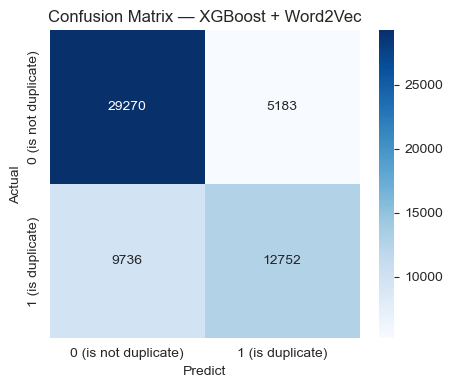

In [276]:
cm_xgb_w2v = confusion_matrix(y_val, val_preds_xgb_w2v)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb_w2v, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (is not duplicate)', '1 (is duplicate)'], yticklabels=['0 (is not duplicate)', '1 (is duplicate)'])
plt.xlabel('Predict')
plt.ylabel('Actual')
plt.title('Confusion Matrix — XGBoost + Word2Vec')
plt.show()

**Conclusion:** word2vec-google-news-300 with XGBoost gave the best result of all approaches so far (log loss 0.489) — and this is the lowest value obtained in the project at this point.

# Does Word2Vec correct the errors of TF-IDF?

In [279]:
val_df['w2v_pred_proba'] = val_proba_xgb_w2v
val_df['w2v_pred'] = val_preds_xgb_w2v

In [289]:
print('Examples of FALSE NEGATIVE (real duplicate that the model missed):')
val_df[val_df.error_type == 'false_negative'][['question1', 'question2', 'pred_proba', 'w2v_pred_proba']].sample(10, random_state=72)

Examples of FALSE NEGATIVE (real duplicate that the model missed):


,question1,question2,pred_proba,w2v_pred_proba
302592,How do I lose weight in just 10 days?,How can I lose fat in 10 days?,0.462466,0.486676
45567,How does Flipkart work?,How do companies like Flipkart actually work?,0.299696,0.426979
151652,How do I get my likes and followers up on Instagram?,How can I boost my followers and likes on Instagram?,0.368592,0.662036
26539,How do I hire a legit hacker?,How can I hire a professional hacker?,0.209000,0.603758
292195,Are there any effective cures for eczema?,Is there any known cure for eczema?,0.413537,0.519628
9695,How do you potty train White Pitbull puppies?,How do I potty train my two-month-old Labrador pup?,0.266766,0.409442
206828,What was it about Seinfeld that kept so many people coming back?,Why do people like Seinfeld so much?,0.214945,0.406137
252773,Why is the firm's marginal cost curve equal supply curve?,How can supply curve tell about marginal cost?,0.296634,0.425828
226894,What are the qualities that you look for in your future wife?,What are the ideal qualities of a wife?,0.334712,0.379781
265932,What are the differences between a MP3 file and FLAC file? Can they be converted?,What is the difference between an MP3 and an FLAC file?,0.197758,0.377575


In [291]:
print('Examples of FALSE POSITIVE (the model incorrectly considers as duplicates):')
val_df[val_df.error_type == 'false_positive'][['question1', 'question2', 'pred_proba', 'w2v_pred_proba']].sample(10, random_state=72)

Examples of FALSE POSITIVE (the model incorrectly considers as duplicates):


,question1,question2,pred_proba,w2v_pred_proba
217474,What comes to your mind when you hear of the word 'Corruption'?,What comes to your mind when you hear the word 'Terrorism'?,0.543090,0.717421
70436,Is Balaji Viswanathan a superhuman?,Is Balaji Viswanathan underrated? Why if so?,0.550957,0.100995
198748,How can I learn & start a digital marketing company?,How can I start my digital marketing company?,0.873781,0.730147
73907,What happened with TPUTH.com?,What happened to Filepile.com?,0.650921,0.169836
252165,What happened to udemydownloader.com?,What happened at Kibu.com?,0.638387,0.160267
231190,What are the advantages of using a mobile phone?,What are the advantages and disadvantages of mobile phones?,0.747613,0.580528
208846,How do you add a video to a question on Quora?,How can I add multimedia to Quora while asking a question?,0.617591,0.595511
136324,Does the capacity of the brain ever stop?,Has your brain ever stopped?,0.839462,0.541947
203415,How do I prepare for the GRE?,What is GRE? How can I prepare for it?,0.625684,0.591940
94122,Why am I not getting job in software industry?,How do I get a job in the software industry?,0.550535,0.737138


# Best model and test data

In [299]:
best_model, best_proba_fn = 'XGBoost (Word2Vec)', xgb_w2v

test_proba = best_proba_fn.predict_proba(X_test)[:, 1]
test_preds = (test_proba >= 0.5).astype(int)

results_test = pd.DataFrame([{
    'model': best_model,
    'log_loss': log_loss(y_test, test_proba),
    'f1': f1_score(y_test, test_preds),
    'accuracy': accuracy_score(y_test, test_preds),
    'roc_auc': roc_auc_score(y_test, test_proba),
}])

print('='*20+'TEST (best model)'+'='*20)
print(results_test)

====================TEST (best model)====================
                model  log_loss        f1  accuracy   roc_auc
0  XGBoost (Word2Vec)  0.422397  0.705551  0.789532  0.873963


The test numbers are noticeably better than the same model's validation results. Let's check if there is overlap between train and test data

In [329]:
train_qids = set(train_df['qid1']) | set(train_df['qid2'])
test_qids = set(test_df['qid1']) | set(test_df['qid2'])
overlap = train_qids & test_qids

print(f'Unique qid in train: {len(train_qids)}')
print(f'Unique qid in test: {len(test_qids)}')
print(f'Overlap train/test: {len(overlap)} ({len(overlap)/len(test_qids)*100:.1f}% of test)')

Unique qid in train: 449787
Unique qid in test: 137780
Overlap train/test: 49638 (36.0% of test)


So, ~36% of the questions in test.csv also appear in train.csv. As a result, the model has partially "seen" a third of the test questions during training, which optimistically biases the test metrics upward.

# Save the results

In [305]:
import pickle

# 1. Save the results tables as CSV files so they can be easily opened
#    and extended in a new notebook
val_results.to_csv('data/results_val.csv', index=False)
train_results.to_csv('data/results_train.csv', index=False)

# results_test - if the final model has already been evaluated on the test set
results_test.to_csv('data/results_test.csv', index=False)

print('Results tables have been saved to data/')

# 2. Save validation prediction probabilities.
#    These will be used to compare ROC curves with BERT
#    in the next notebook without retraining the TF-IDF/Word2Vec models.
val_predictions = {
    'y_val': y_val,
    'LogReg_TFIDF': val_proba_lr,
    'XGBoost_TFIDF': val_proba_xgb,
    'LogReg_Word2Vec': val_proba_lr_w2v,
    'XGBoost_Word2Vec': val_proba_xgb_w2v,
}

with open('data/val_predictions.pkl', 'wb') as f:
    pickle.dump(val_predictions, f)

print('Validation prediction probabilities have been saved to data/val_predictions.pkl')

Results tables have been saved to data/
Validation prediction probabilities have been saved to data/val_predictions.pkl


In [326]:
# Save datasets

feature_cols_to_save = [
    'common_word_count', 'union_word_count', 'word_share_jaccard',
    'common_over_min_len', 'common_over_max_len', 'token_len_diff', 'char_len_diff',
    'tfidf_cosine', 'tfidf_euclidean', 'tfidf_manhattan',
    'w2v_avg_cosine', 'w2v_avg_euclidean', 'w2v_avg_manhattan',
    'w2v_weighted_cosine', 'w2v_weighted_euclidean', 'w2v_weighted_manhattan',
]
base_cols = ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']

train_df.iloc[train_idx][base_cols + feature_cols_to_save].to_csv('data/train_features_full.csv', index=False)
train_df.iloc[val_idx][base_cols + feature_cols_to_save].to_csv('data/val_features_full.csv', index=False)
test_df[base_cols + feature_cols_to_save].to_csv('data/test_features_full.csv', index=False)

print('Saved: train_features_full.csv, val_features_full.csv, test_features_full.csv')
print('Shape train:', train_df.iloc[train_idx][base_cols + feature_cols_to_save].shape)
print('Shape val:  ', train_df.iloc[val_idx][base_cols + feature_cols_to_save].shape)

Saved: train_features_full.csv, val_features_full.csv, test_features_full.csv
Shape train: (266488, 22)
Shape val:   (56941, 22)
